# QSVT
----

## 数学原理

### 1. 从 QSP 到 QSVT
上一节 QSP 的核心是
$$
x\mapsto P(x)
$$
但真正的问题通常不是标量, 而是矩阵 $A$. 于是问题变成了
> 能否将 $x\mapsto P(x)$ 推广为矩阵变换

对于 Hermitian matrix, 最直观的是
$$
A=\sum_j \lambda_j\ket{u_j}\bra{u_j}
$$
我们希望
$$
A\mapsto P(A)=\sum_j P(\lambda_j)\ket{u_j}\bra{u_j}
$$
而对于一般的 non-Hermitian matrix, 连 eigenvalue decomposition 都无法保证.

### 2. Singular Value Decomposition (SVD)
任意矩阵可以写成
$$
A=\sum_j \sigma_j\ket{u_j}\bra{v_j}
$$
也就是
$$
A=U\Sigma V^\dagger
$$
其中 $\sigma_j\geq 0$ 是矩阵的奇异值. 并且满足
$$
A\ket{v_j}=\sigma_j\ket{u_j},\quad A^\dagger\ket{u_j}=\sigma_j\ket{v_j}
$$
所以 QSVT 的目标不再是
$$
\lambda_j\mapsto P(\lambda_j)
$$
而是
$$
\sigma_j\mapsto P(\sigma_j)
$$

### 3. 奇 QSVT 变换
对于适合的奇多项式
$$
P(-x)=-P(x)
$$
QSVT 对于
$$
A=\sum_j \sigma_j \ket{u_j}\bra{v_j}
$$
产生
$$
P^{(SV)}(A)=\sum_j P(\sigma_j)\ket{u_j}\bra{v_j}
$$
注意一般不是 $P(A)$. 对于 non-Hermitian 的矩阵, 通常成立
$$
P^{(SV)}(A)\neq P(A)
$$

### 4. 为什么奇偶性再次出现
可以用 Hermitian dilation 来理解. 定义
$$
\mathcal{H}_A=\begin{bmatrix}
0 & A \\
A^\dagger & 0
\end{bmatrix}
$$
和
$$
\ket{L_j}=\begin{bmatrix}
\ket{u_j}\\
0
\end{bmatrix},\quad \ket{R_j}=\begin{bmatrix}
0\\
\ket{v_j}
\end{bmatrix}
$$
则有
$$
\mathcal{H}_A\ket{L_j}=\sigma\ket{R_j},\quad \mathcal{H}_A\ket{R_j}=\sigma\ket{L_j}
$$
所以在二维子空间 $span\{\ket{L_j},\ket{R_j}\}$ 中, 有
$$
\mathcal{H}_A\sim \sigma_j X
$$
其本征值为 $\pm\sigma_j$, 于是 QSVT 变为 QSP 问题.

### 5. 本节统一实验
选择矩阵
$$
A=\begin{bmatrix}
1 & 0 \\
0 & 0.5
\end{bmatrix}
$$
其奇异值为 $\sigma_1=1,\sigma_2=0.5$,并且 $\|A\|=1$. 条件数为 
$$
\kappa=\frac{\sigma_{max}}{\sigma_{min}}=2
$$

### 6. 第一个 QSVT 实验: $p(x)=x^3$
先选择一个简单的多项式
$$
P(x)=x^3
$$
则有
$$
\sigma_1=1\to P(\sigma_1)=1,\qquad \sigma_2=0.5\to P(\sigma_2)=0.125
$$
所以矩阵 A 经过 QSVT 后应变为
$$
P(A)=\begin{bmatrix}
1 & 0 \\
0 & 0.125
\end{bmatrix}
$$

In [1]:
# 官方实现
import numpy as np
from unitarylab.library import QSVT

%matplotlib inline

A = np.array([[1.0, 0.0], [0.0, 0.5]], dtype=complex)


def cubic_function(x):
    """目标函数"""
    return x**3


qsvt = QSVT(
    A,
    function=cubic_function,
    target_error=1e-6,
    block_encoding_method="nagy",
    device="cpu",
)

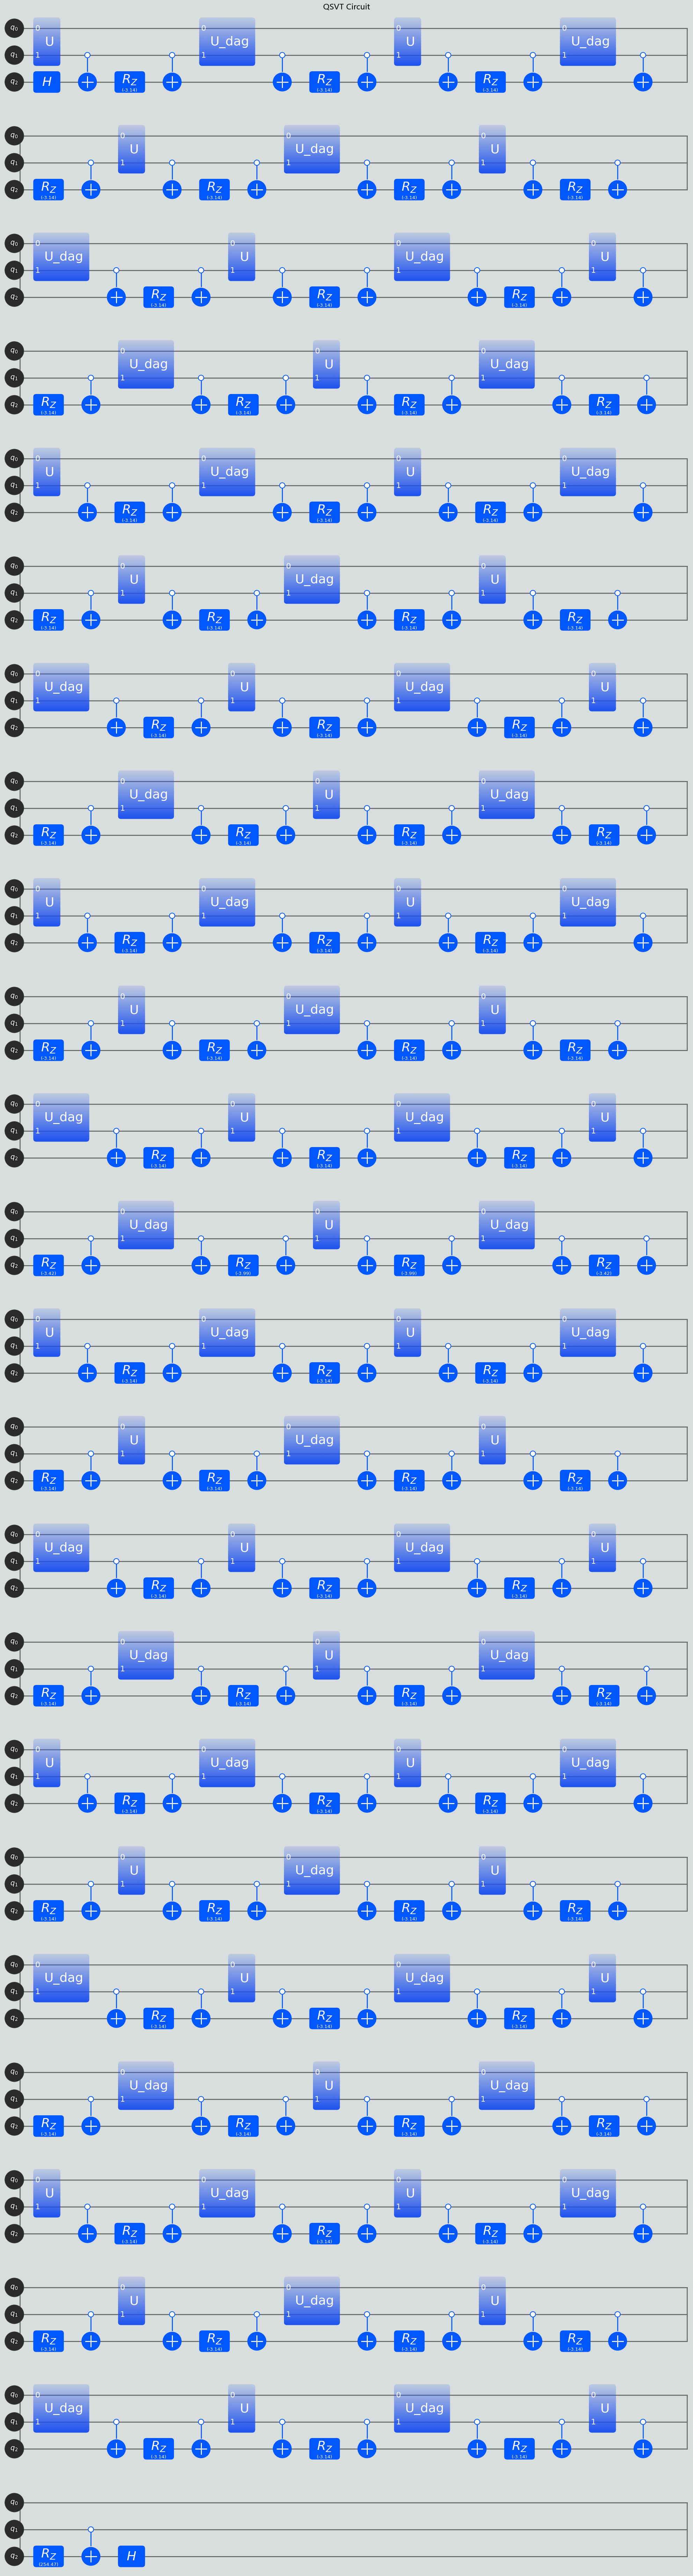

In [2]:
# 绘制线路
qsvt_circuit = qsvt.circuit
_ = qsvt_circuit.draw(title="QSVT Circuit")

In [3]:
# 读取基本元素
print("QSVT degree =", qsvt.degree)
print("Block-encoding alpha =", qsvt.alpha)
print("Ancilla count m =", qsvt.m)
print("Official QSVT error =", qsvt.total_error)

QSVT degree = 81
Block-encoding alpha = 1.0
Ancilla count m = 1
Official QSVT error = 8.486544800591985e-13


In [4]:
# 官方输出矩阵
official_qsvt_matrix = np.asarray(qsvt.evolution_result)

# 理论输出矩阵
expected_cubic = A @ A @ A

# 打印检查
print("Expected A^3 =\n", expected_cubic)
print("Official QSVT =\n", official_qsvt_matrix)

Expected A^3 =
 [[1.   +0.j 0.   +0.j]
 [0.   +0.j 0.125+0.j]]
Official QSVT =
 [[1.00000000e+00+0.j 0.00000000e+00+0.j]
 [7.65404249e-18+0.j 1.25000000e-01+0.j]]


In [5]:
# 手写 QSVT
def singular_value_transfrom(matrix, function):
    U, singular_values, Vh = np.linalg.svd(matrix)
    transformed_values = function(singular_values)

    return U @ np.diag(transformed_values) @ Vh


manual_qsvt_matrix = singular_value_transfrom(A, lambda x: x**3)

print("Manual QSVT =\n", manual_qsvt_matrix)

Manual QSVT =
 [[1.   +0.j 0.   +0.j]
 [0.   +0.j 0.125+0.j]]


In [6]:
# 手写对比官方
manual_qsvt_error = np.linalg.norm(manual_qsvt_matrix - expected_cubic)
official_vs_manual = np.linalg.norm(official_qsvt_matrix - manual_qsvt_matrix)

print("Manual error =", manual_qsvt_error)
print("Official vs Manual =", official_vs_manual)

Manual error = 0.0
Official vs Manual = 8.629386999439121e-13


### 1. 现在考虑线性系统
考虑线性系统
$$
Ax=b
$$
若 $A=U\Sigma V^\dagger$, 则有
$$
A^{-1}=V\Sigma^{-1}U^\dagger
$$
所以
$$
A^{-1}:\sigma_j\to \frac{1}{\sigma_j}
$$
这就是一个 singular value transform.

### 2. 为什么不能直接选择 $P(x)=1/x$?
因为 $1/x$ 在 $x=0$ 处发散.但 QSP/QSVT 多项式必须是有限的多项式, 所以不可能在整个 $[-1, 1]$ 区间上逼近 $1/x$. 只能要求谱离开0.

若
$$
\kappa=\frac{\sigma_{\max}}{\sigma_{\min}}
$$
归一化后 singular spectrum 位于
$$
\sigma\in\left[\frac{1}{\kappa},1\right]
$$
因为其逆也是奇函数, 也考虑
$$
[-1,-1/\kappa]\cup[1/\kappa,1]
$$
所以真正的目标是
$$
P(x)\approx\frac{c}{x},\quad |x|\geq \frac{1}{\kappa}
$$
这也是 QSVT 矩阵求逆的思路. 逆多项式的阶数与条件数和目标精度紧密相关.

### 3. 为什么有缩放因子 c?
若直接
$$
P(x)\approx \frac{1}{x}
$$
则在 $x=\frac{1}{\kappa}$ 处会有
$$
|P(x)|\approx \kappa
$$
这通常会超过 QSVT 可直接实现的振幅范围.

因此选择
$$
c=\frac{1}{\kappa}
$$
目标就变为
$$
f_{inv}(x)=\frac{1}{\kappa x}
$$
于是对于 $|x|\geq \frac{1}{\kappa}$, 有
$$
|f_{inv}(x)|\leq 1
$$
更重要的是
$$
P(A)\approx \frac{1}{\kappa}A^{-1}
$$
虽然多了 $\frac{1}{\kappa}$, 但量子解态最后要归一化
$$
\frac{A^{-1}\ket{b}}{\|A^{-1}\ket{b}\|}
$$
因此整体比例不会改变解态方向.

### 4. 本例中的逆变换
此例子
$$
A=\begin{bmatrix}
1 & 0 \\
0 & 0.5
\end{bmatrix}
$$
条件数为 $\kappa=2$, 所以 $c=\frac{1}{2}$. 目标函数为
$$
f_{inv}(x)=\frac{1}{2x}
$$
两个奇异值变为
$$
1\to \frac{1}{2}\quad 0.5\to 1
$$
所以
$$
P^{SV}(A)\approx=\begin{bmatrix}
0.5 & 0 \\
0 & 1
\end{bmatrix}
$$
而且
$$
\frac{1}{2}A^{-1}=\frac{1}{2}\begin{bmatrix}
1 & 0 \\
0 & 2
\end{bmatrix}=\begin{bmatrix}
0.5 & 0 \\
0 & 1
\end{bmatrix}
$$
非常直观.

### 5. 手写逆多项式
使用 Chebyshev 基
$$
P_d(x)=\sum_{k=0}^d c_kT_k(x)
$$
因为 $1/x$ 是奇函数, 所以只保留
$$
T_1, T_3, T_5, \cdots
$$
取 $d=25$.

In [7]:
from numpy.polynomial.chebyshev import chebval, chebvander

kappa = np.linalg.norm(A)
degree = 25
sigma_min = 1.0 / kappa

# 构造拟合区间
n_samples = 600

x_positive = np.linspace(sigma_min, 1.0, n_samples // 2)
x_negative = -x_positive[::-1]

x_samples = np.concatenate([x_negative, x_positive])

# 目标
y_samples = 1.0 / (kappa * x_samples)

# 只拟合奇数项
vandermonde = chebvander(x_samples, degree)
odd_indices = np.arange(1, degree + 1, 2)

# 拟合
odd_coefficients, *_ = np.linalg.lstsq(
    vandermonde[:, odd_indices], y_samples, rcond=None
)

inverse_coefficients = np.zeros(degree + 1)
inverse_coefficients[odd_indices] = odd_coefficients


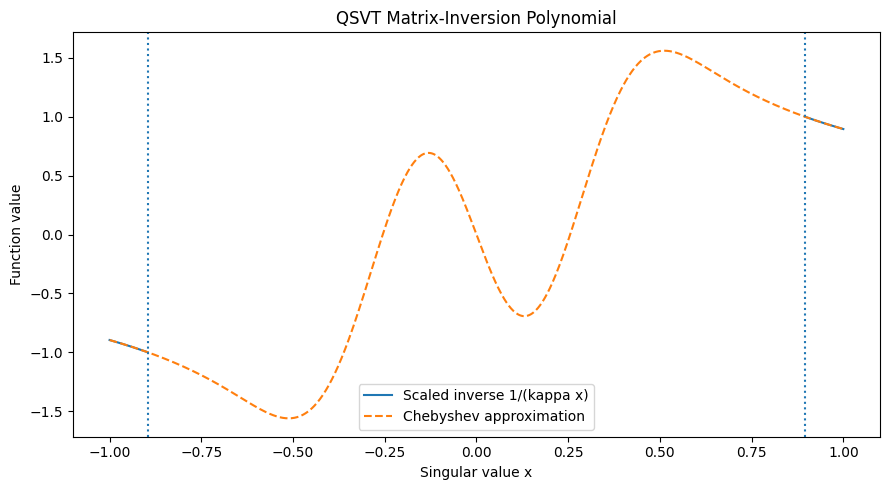

In [8]:
import matplotlib.pyplot as plt

x_grid = np.linspace(-1.0, 1.0, 1001)

polynomial_values = chebval(x_grid, inverse_coefficients)
target_values = np.full(x_grid.shape, np.nan)

valid_region = np.abs(x_grid) >= sigma_min
target_values[valid_region] = 1.0 / (kappa * x_grid[valid_region])

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(x_grid, target_values, label="Scaled inverse 1/(kappa x)")
ax.plot(x_grid, polynomial_values, linestyle="--", label="Chebyshev approximation")

ax.axvline(float(sigma_min), linestyle=":")
ax.axvline(float(-sigma_min), linestyle=":")

ax.set_xlabel("Singular value x")
ax.set_ylabel("Function value")
ax.set_title("QSVT Matrix-Inversion Polynomial")
ax.legend()

fig.tight_layout()

plt.show()

In [9]:
# 检查多项式逼近
approx_samples = chebval(x_samples, inverse_coefficients)

inverse_fit_error = np.max(np.abs(approx_samples - y_samples))

print("Maximum inverse-polynomial error =", inverse_fit_error)

Maximum inverse-polynomial error = 1.0758061108617767e-13


In [10]:
# 进行 SVD
U, singular_values, Vh = np.linalg.svd(A)

transformed_singular_values = chebval(singular_values, inverse_coefficients)
manual_inverse_transform = U @ np.diag(transformed_singular_values) @ Vh

exact_scaled_inverse = np.linalg.inv(A) / kappa

# 比较
print("Manual QSVT inverse =\n", manual_inverse_transform)
print("Exact scaled inverse =\n", exact_scaled_inverse)

Manual QSVT inverse =
 [[0.89442719+0.j 0.        +0.j]
 [0.        +0.j 1.55593428+0.j]]
Exact scaled inverse =
 [[0.89442719+0.j 0.        +0.j]
 [0.        +0.j 1.78885438+0.j]]


In [11]:
# 误差
manual_inverse_error = np.linalg.norm(manual_inverse_transform - exact_scaled_inverse)

print("Inverse-transform error =", manual_inverse_error)

Inverse-transform error = 0.2329201023485863


真正求解 $Ax=b$. 选择
$$
\ket{b}=\frac{\ket{0}+\ket{1}}{\sqrt{2}}
$$

In [12]:
# 创建|b>
b = np.array([1.0, 1.0], dtype=complex)
b = b / np.linalg.norm(b)

# 精确解
x_exact = np.linalg.solve(A, b)

x_exact_state = x_exact / np.linalg.norm(x_exact)

本例
$$
x_{exact}=\frac{1}{\sqrt{2}}\begin{bmatrix}
1\\
2
\end{bmatrix}
$$
解应为
$$
\ket{x}=\frac{\ket{0}+2\ket{1}}{\sqrt{5}}
$$
因此
$$
\ket{x}=\begin{bmatrix}
1/\sqrt{5}\\
2/\sqrt{5}\\
\end{bmatrix}
$$
概率为
$$
P(0)=0.2\quad P(1)=0.8
$$

In [13]:
x_manual = manual_inverse_transform @ b
x_manual_state = x_manual / np.linalg.norm(x_manual)

print("Exact solution state =", x_exact_state)
print("Manual QSVT state =", x_manual_state)

Exact solution state = [0.4472136 +0.j 0.89442719+0.j]
Manual QSVT state = [0.49837271+0.j 0.86696289+0.j]


量子态可能会相差 global phase, 所以不能直接要求两个量子态相等, 而是计算保真度(fidelity):
$$
F=|\braket{x_{exact}|x_{manual}}|^2
$$
若 $F\approx 1$, 则认为两个量子态相等.

In [14]:
manual_fidelity = abs(np.vdot(x_exact_state, x_manual_state)) ** 2

print("Manual fidelity =", manual_fidelity)

Manual fidelity = 0.9966312990902688


[QSVT_QLSA]: Starting QSVT Linear Solver
[QSVT_QLSA]: Input parameters: 
        - Matrix in the linear system = [[1. +0.j 0. +0.j]
 [0. +0.j 0.5+0.j]]
        - Source vector = [0.70710678+0.j 0.70710678+0.j]
        - Target precision (epsilon) = 0.001
[QSVT_QLSA]: Calling the QSVT linear solver from unitarylab...
[QSVT_QLSA] Starting QSVT linear solver (target precision=0.001)
[QSVT_QLSA] Stage 1/4: Classical preprocessing (computing Chebyshev approximation coefficients)...
  - Matrix condition number (kappa): 2.0
  - Block-Encoding factor (alpha): 1.0
  - Highest truncated polynomial degree: 41
[QSVT_QLSA] Stage 1/4 complete ✓
[QSVT_QLSA] Stage 2/4: Building QSVT quantum circuit...
  - Loaded normalized source state |b>
  - Calling QSP engine to generate polynomial Block-Encoding circuit...
[QSVT_QLSA] Stage 2/4 complete ✓
[QSVT_QLSA] Stage 3/4: Running quantum simulation...
  - Core simulation time: 0.0060 s
[QSVT_QLSA] Stage 3/4 complete ✓
[QSVT_QLSA] Stage 4/4: Running classical

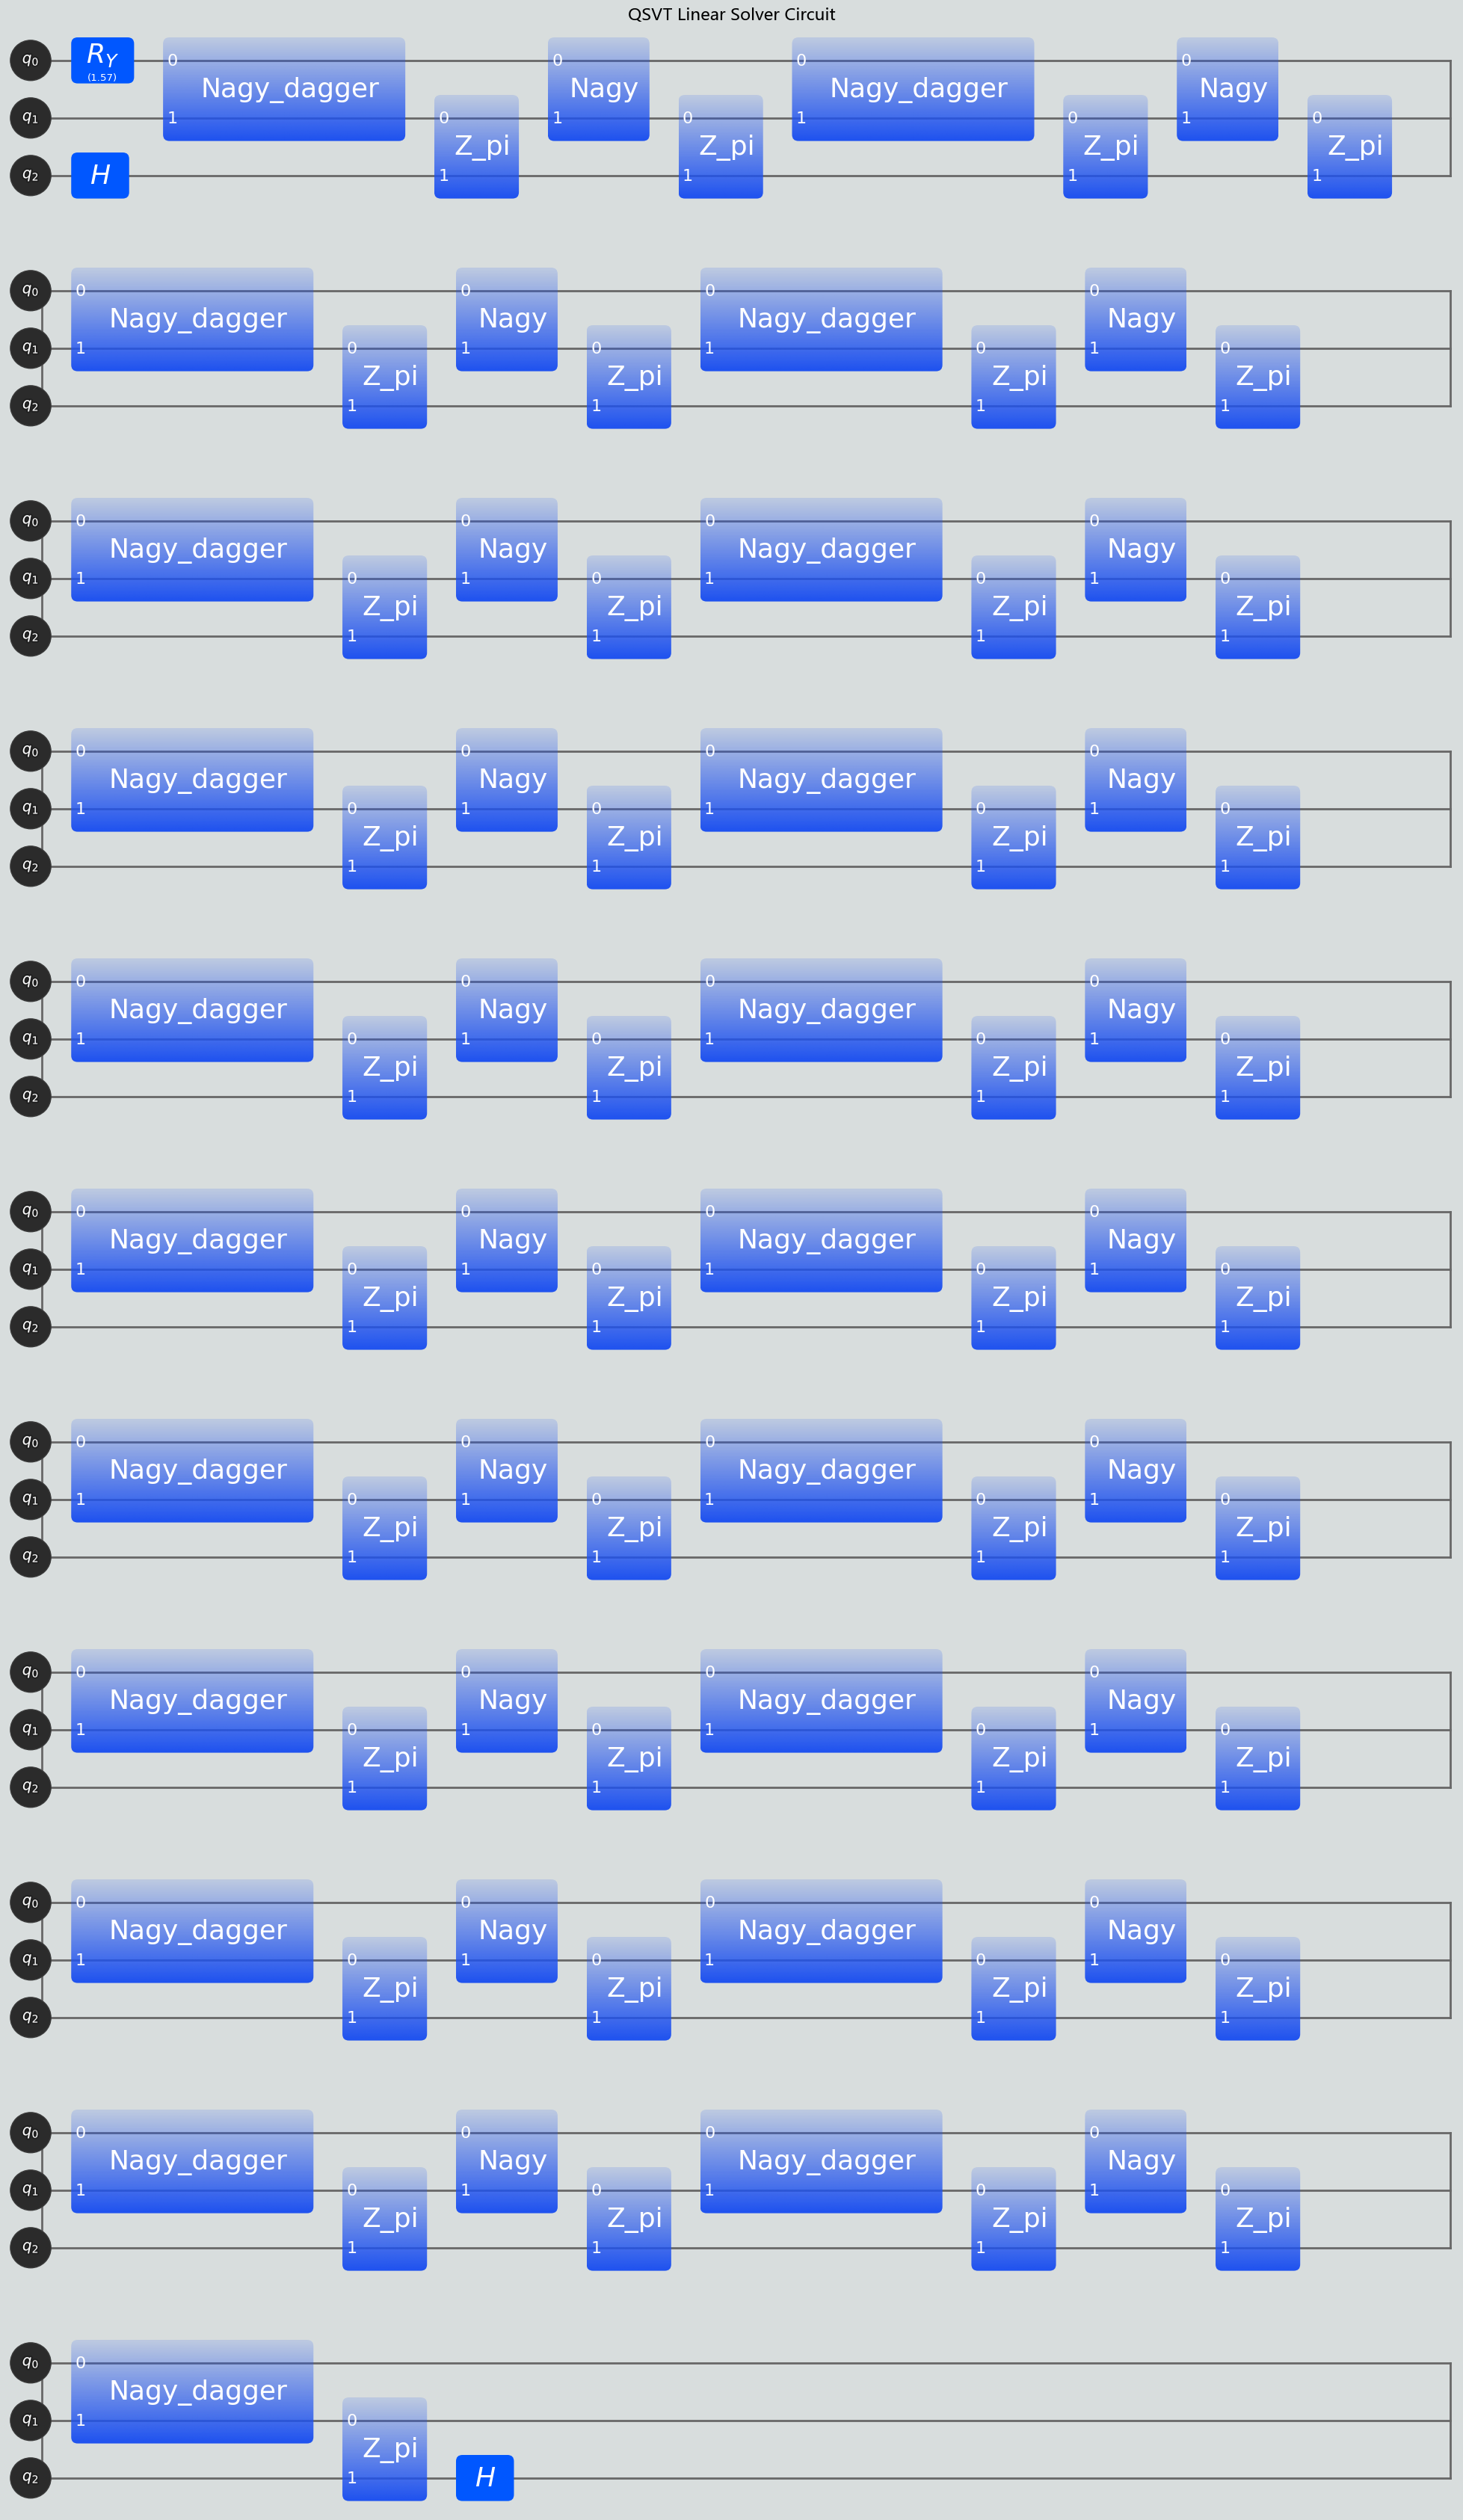

In [15]:
# 官方实现
from unitarylab_algorithms import QSVTLinearSolverAlgorithm

%matplotlib inline

qsvt_solver = QSVTLinearSolverAlgorithm(text_mode="plain")
solver_result = qsvt_solver.run(
    A=A, b=b, epsilon=1e-3, backend="numpy", device="cpu", dtype=np.complex128
)


In [16]:
# 读取结果
official_solution = np.asarray(solver_result["Solution vector"], dtype=complex)
official_scale = solver_result["Scaling factor applied"]

print("Official solution =", official_solution)
print("Scaling factor =", official_scale)

Official solution = [0.70710679+0.j 1.41402416+0.j]
Scaling factor = 3.9999999999999996


In [17]:
# 转化为量子态
official_solution_state = official_solution / np.linalg.norm(official_solution)

# 计算保真度
official_fidelity = abs(np.vdot(x_exact_state, official_solution_state)) ** 2

print("Official Solution Fidelity:", official_fidelity)

Official Solution Fidelity: 0.9999999971286744


In [18]:
print("\n========== QSVT Linear Solver ==========")
print("Exact normalized solution =", x_exact_state)
print("Manual normalized solution =", x_manual_state)
print("Official normalized solution =", official_solution_state)
print("\nManual fidelity =", manual_fidelity)
print("Official fidelity =", official_fidelity)


========== QSVT Linear Solver ==========
Exact normalized solution = [0.4472136 +0.j 0.89442719+0.j]
Manual normalized solution = [0.49837271+0.j 0.86696289+0.j]
Official normalized solution = [0.44726152+0.j 0.89440323+0.j]

Manual fidelity = 0.9966312990902688
Official fidelity = 0.9999999971286744


In [19]:
manual_unscaled_solution = kappa * x_manual
manual_residual = np.linalg.norm(A @ manual_unscaled_solution - b)

exact_residual = np.linalg.norm(A @ x_exact - b)

print("Exact residual:", exact_residual)
print("Manual residual:", manual_residual)

Exact residual: 0.0
Manual residual: 0.09206975453263344


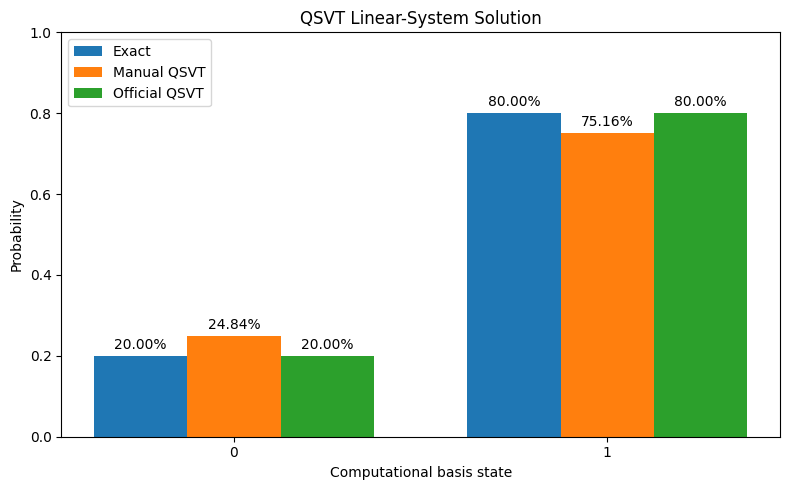

In [20]:
# 比较概率图
exact_probabilities = np.abs(x_exact_state) ** 2
manual_probabilities = np.abs(x_manual_state) ** 2
official_probabilities = np.abs(official_solution_state) ** 2

basis_states = [
    "0",
    "1",
]

positions = np.arange(len(basis_states))

width = 0.25

fig, ax = plt.subplots(figsize=(8, 5))

bars_exact = ax.bar(positions - width, exact_probabilities, width, label="Exact")
bars_manual = ax.bar(positions, manual_probabilities, width, label="Manual QSVT")
bars_official = ax.bar(
    positions + width, official_probabilities, width, label="Official QSVT"
)

ax.bar_label(
    bars_exact, labels=[f"{p * 100:.2f}%" for p in exact_probabilities], padding=3
)
ax.bar_label(
    bars_manual, labels=[f"{p * 100:.2f}%" for p in manual_probabilities], padding=3
)
ax.bar_label(
    bars_official, labels=[f"{p * 100:.2f}%" for p in official_probabilities], padding=3
)

ax.set_xticks(positions)
ax.set_xticklabels(basis_states)

ax.set_xlabel("Computational basis state")
ax.set_ylabel("Probability")
ax.set_title("QSVT Linear-System Solution")

ax.set_ylim(0, 1.0)
ax.legend()
fig.tight_layout()

plt.show()